#  Credit Ratings Prediction for Bank

---
embed-resources: true
---

## Introduction

Credit ratings are essential for assessing loan risk, but relying on credit agencies can be costly for the bank. This analysis explores whether a K-Nearest Neighbors (KNN) model can accurately predict credit ratings using demographic and income data. We evaluate the model’s performance based on prediction accuracy, RMSE, and potential misclassification risks. 

## Methods

In [1]:
# imports

# basic imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# machine learning imports
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error

# preprocessing imports
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

### Data

In [2]:
# load data
credit_train = pd.read_parquet("https://cs307.org/lab/data/credit-train.parquet")
credit_test = pd.read_parquet("https://cs307.org/lab/data/credit-test.parquet")

#### Data Dictionary

Each observation in the train, test, and (hidden) production data contains information about a particular banking customer. For the purposes of this lab, we assume that these are from a bank operating and with customers located in the United States.

#### Response
`Rating`

- `[float64]` credit rating, specifically the credit score of an individual consumer
#### Features

`Income`

- `[float64]` yearly income in $1000s

`Age`

- `[float64]` age

`Education`

- `[float64]` years of education completed

`Gender`

- `[object]` gender

`Student`

- `[object]` a Yes / No variable with Yes indicating an individual is a student

`Married`

- `[object]` a Yes / No variable with Yes indicating an individual is married

`Ethnicity`

- `[object]` ethnicity

In [3]:
# summary statistics
credit_train[['Rating','Income','Age','Education']].describe()

,Rating,Income,Age,Education
count,256.000000,256.000000,223.000000,231.000000
mean,347.609375,43.276848,55.730942,13.454545
std,148.893105,33.580289,17.298890,3.205479
min,93.000000,10.403000,24.000000,5.000000
25%,242.500000,21.340000,42.000000,11.000000
50%,340.500000,31.589000,56.000000,14.000000
75%,433.000000,55.054500,69.000000,16.000000
max,982.000000,186.634000,98.000000,20.000000


The correlation between Rating and Age is quite low (0.143), indicating a weak linear relationship between these two variables. Given this weak correlation, we will not include Age as a predictor in our model, as it is unlikely to contribute significantly to the prediction of Rating. Instead, we will focus on variables with stronger correlations, such as Income, which has a notable correlation of 0.770 with Rating.

Text(0, 0.5, 'Rating')

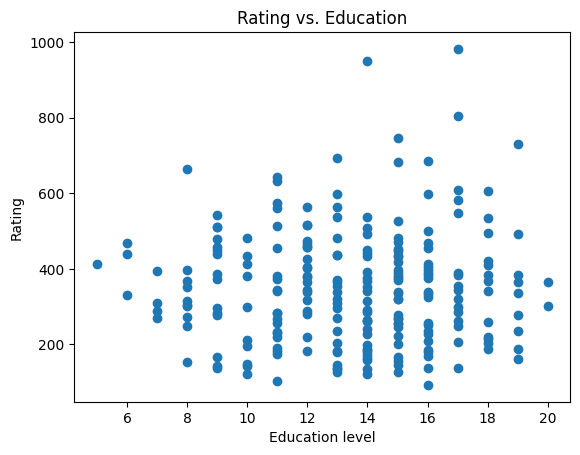

In [4]:
# exploratory visualization
plt.scatter(credit_train['Education'],credit_train['Rating'])
plt.title('Rating vs. Education')
plt.xlabel('Education level')
plt.ylabel('Rating')

Even though years of education is a numerical variable, it can be treated as categorical for better analysis. Education levels are typically understood in discrete stages (e.g., 12 years for high school, 16 years for a bachelor's degree, etc.), making it more meaningful to categorize them rather than treat them as a continuous scale. 

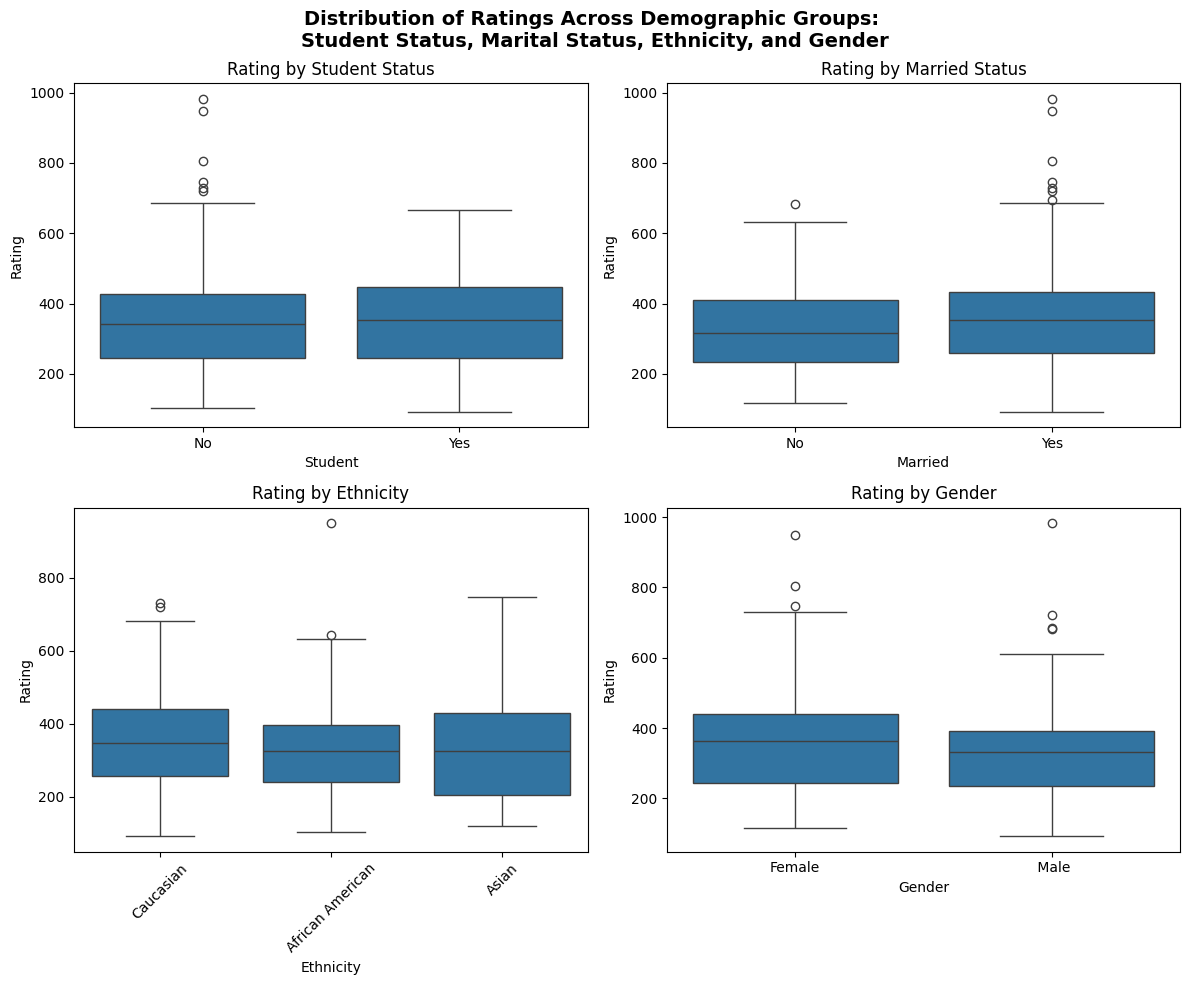

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

fig.suptitle("Distribution of Ratings Across Demographic Groups: \nStudent Status, Marital Status, Ethnicity, and Gender", fontsize=14, fontweight='bold')

# Box plot for Student
sns.boxplot(ax=axes[0, 0], x="Student", y="Rating", data=credit_train)
axes[0, 0].set_title("Rating by Student Status")

# Box plot for Married
sns.boxplot(ax=axes[0, 1], x="Married", y="Rating", data=credit_train)
axes[0, 1].set_title("Rating by Married Status")

# Box plot for Ethnicity
sns.boxplot(ax=axes[1, 0], x="Ethnicity", y="Rating", data=credit_train)
axes[1, 0].set_title("Rating by Ethnicity")
axes[1, 0].tick_params(axis='x', rotation=45)  # Rotate x labels for readability

# Box plot for Gender
sns.boxplot(ax=axes[1, 1], x="Gender", y="Rating", data=credit_train)
axes[1, 1].set_title("Rating by Gender")

# Adjust layout
plt.tight_layout()
plt.show()

The boxplots compare the distribution of ratings across different demographic categories: student status, marital status, ethnicity, and gender. From the graphs, it is evident that student and marital status do not show significant differences in their distributions, as the median values and inter quartile ranges are quite similar between groups. Similarly, gender does not appear to have a strong impact on ratings, as both male and female distributions are nearly identical, with only minor variations in outliers. However, ethnicity presents noticeable differences in rating distributions, with varying spreads and a greater presence of outliers. This suggests that ethnicity may have a more meaningful impact on ratings compared to the other factors. Therefore, we will focus our analysis on ethnicity, as it provides more variation and potential insights, while student status, marital status, and gender do not show significant distinctions.

### Models

In [6]:
# process data for ML

# create X and y for train
X_train = credit_train.drop("Rating", axis=1)
y_train = credit_train["Rating"]

# create X and y for test
X_test = credit_test.drop("Rating", axis=1)
y_test = credit_test["Rating"]

In [7]:
credit_train.isna().sum()/256

Rating       0.000000
Income       0.000000
Age          0.128906
Education    0.097656
Gender       0.023438
Student      0.093750
Married      0.000000
Ethnicity    0.097656
dtype: float64

There is some missing value in the data, So we need a preprocessor to handle it.

In [17]:
numeric_features = ['Income',]
categorical_features = ['Ethnicity','Education','Gender']
features = numeric_features + categorical_features
target = "Rating"

In [18]:
# train models
knn = KNeighborsRegressor()
# define preprocessing for numeric features
numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median"),
)

# define preprocessing for categorical features
categorical_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="infrequent_if_exist"),
)

# create general preprocessor
preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (categorical_transformer, categorical_features),
    remainder="drop",
)
# define the parameter grid
param_grid = {
    "kneighborsregressor__n_neighbors": [1, 5, 10, 15, 20, 25],
    "kneighborsregressor__p": [1, 2],
}

# create the pipeline
pipeline = make_pipeline(
    preprocessor,
    knn,
)

# create the grid search
mod = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
)

# fit the grid search
mod.fit(X_train, y_train)

# print the best parameters and the corresponding score
print(f"Best Parameters: {mod.best_params_}")
print(f"Best Cross-Validated RMSE: {mod.best_score_}")

Best Parameters: {'kneighborsregressor__n_neighbors': 15, 'kneighborsregressor__p': 2}
Best Cross-Validated RMSE: -102.04006850652009


We developed a regression model using the K-Nearest Neighbors (KNN) algorithm as the primary model. To ensure handling the null value, we implemented a pipeline that handles both numerical and categorical features appropriately.

For numerical features, we applied median imputation to address missing values and standardization to normalize feature scales. Categorical features underwent most frequent imputation for missing values and were one-hot encoded to convert them into a numerical format suitable for modeling.

To optimize the model, we conducted a grid search with 5-fold cross-validation using GridSearchCV. The parameters tuned included the number of neighbors (n_neighbors), tested at values of 1, 5, 10, 15, 20, and 25, and the distance metric (p), evaluated at 1 (Manhattan distance) and 2 (Euclidean distance). The best parameters were selected based on the negative root mean squared error (RMSE).

The optimal values identified were:

n_neighbors = 15
p = 2 (Euclidean distance)
The best cross-validated RMSE was 102.04, indicating the model's predictive performance.

The RMSE (Root Mean Squared Error) value of 102.04 indicates the average deviation of the model’s predicted credit ratings from the actual values.The RMSE of 102.04 means that, on average, the model's predicted credit rating deviates from the actual rating by about 102 points. This typical error suggests that individual predictions can be off by this margin in either direction.

## Results

In [19]:
# report model metrics

final_model = make_pipeline(
    preprocessor,
    KNeighborsRegressor(n_neighbors=15,p=2),
)
final_model.fit(X_train, y_train)

# predict on the test data
y_test_pred = final_model.predict(X_test)

# calculate and print the test accuracy
test_RMSE = root_mean_squared_error(y_test, y_test_pred)
print(f"Test RMSE: {test_RMSE}")

Test RMSE: 107.03523984858653


The K-Nearest Neighbors (KNN) model achieved a test RMSE of 107.035. The Test RMSE of 107.035 means that, on average, the model’s predicted credit ratings deviate from the actual ratings by about 108 points. 

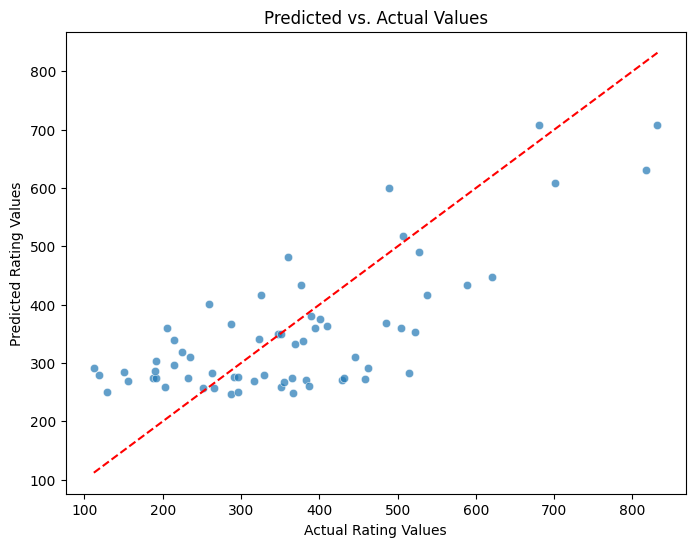

In [11]:
# Create a scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Perfect prediction line
plt.xlabel("Actual Rating Values")
plt.ylabel("Predicted Rating Values")
plt.title("Predicted vs. Actual Values")
plt.show()

The scatter plot compares predicted credit ratings with actual values, with the red dashed line representing a perfect prediction where the two would be equal. Ideally, if the model were accurate, the points would closely align along this line. However, the plot shows significant deviations, with many points scattered far from the ideal trend. The model tends to underestimate higher credit ratings and overestimate lower credit ratings, indicating that it struggles to distinguish between individuals with different creditworthiness levels. Additionally, the high variability in predictions suggests that the model has a substantial amount of error and inconsistency, making it unreliable for practical use.

In [20]:
# serialize model
from joblib import dump
dump(final_model, "credit.joblib")

['credit.joblib']

## Discussion

Given the results of our analysis, we would not use this model in practice due to its poor predictive performance and high error rate. The scatter plot comparing predicted and actual credit ratings demonstrates that the model fails to accurately estimate creditworthiness, with significant deviations from the ideal prediction line. Additionally, the RMSE of approximately 108 indicates that, on average, the model’s predictions are off by more than 100 points, which is a substantial error given that credit scores range from 300 to 850. This level of inaccuracy could lead to misclassifications of customers, resulting in high-risk loans being approved or creditworthy customers being denied, both of which could negatively impact the bank’s financial stability and customer relationships.

Since the current model does not meet the necessary standards, improvements must be made before considering its use in practice. One potential improvement is incorporating more relevant financial data, such as credit payment history, outstanding loans, and credit utilization ratio. Another avenue is exploring more advanced machine learning techniques, such as gradient boosting models or neural networks, which may provide better predictive power. However, in its current state, the risks of financial misjudgment and regulatory compliance issues make it unsuitable for practical implementation. Bank will lose a lot of money if they use this model to predict the credit rating of the customers.